# 04 — Final Held-Out Test Evaluation
### Confirmatory Verification of Pre-Specified Primary and Comparator Models
**Author:** Felix (Thesis Research)  
**Pipeline Phase:** Phase 5 Final Evaluation Verification (Post-Opening Audit)  
**Execution Mode:** Strictly Read-Only Metric Verification on Frozen Predictions (Zero Model Fitting)  

---

## 1. Purpose of the Confirmatory Test

This notebook presents the **confirmatory final evaluation** of the primary Generalized Additive Model (GAM) and its two comparator models on the **held-out final test cohort ($N = 812$)**.
* **One-Time Evaluation Rule:** In accordance with strict experimental governance, the held-out final test partition was authorized to be opened **exactly once**.
* **Zero Post-Test Tuning:** All hyperparameters, scalers, and decision thresholds were permanently frozen before test set opening. **No model fitting, no prediction regeneration, no threshold adjustment, and no recalibration is performed in this notebook.**
* **Source of Truth:** All evaluations in this notebook operate directly on the immutable, cryptographically hashed final prediction vector (`predictions_phase5/final_test_predictions.csv`).


In [1]:
import sys, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, roc_curve, precision_recall_curve, confusion_matrix
from sklearn.calibration import calibration_curve

# Configure clean aesthetic plotting
plt.rcParams.update({
    'font.sans-serif': 'DejaVu Sans',
    'figure.autolayout': True,
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8
})

# Robust path resolution independent of working directory
current = Path.cwd().resolve()
candidates = [current, current.parent, current.parent.parent]
PROJECT_ROOT = None
for c in candidates:
    if (c / "nhanes_feasibility_2021_2023").exists():
        PROJECT_ROOT = c
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = current

NHANES_DIR = PROJECT_ROOT / "nhanes_feasibility_2021_2023"
PRED_DIR = NHANES_DIR / "predictions_phase5"
REPORTS_DIR = NHANES_DIR / "reports_phase5"
LOCK_DIR = NHANES_DIR / "lock_phase4_2"

print(f"Project Root:         {PROJECT_ROOT}")
print(f"Phase 5 Predictions:  {PRED_DIR}")
print(f"Phase 5 Reports:      {REPORTS_DIR}")


Project Root:         C:\Users\Felix\Documents\Skripsi
Phase 5 Predictions:  C:\Users\Felix\Documents\Skripsi\nhanes_feasibility_2021_2023\predictions_phase5
Phase 5 Reports:      C:\Users\Felix\Documents\Skripsi\nhanes_feasibility_2021_2023\reports_phase5


## 2. Integrity Verification & Frozen Predictions

Before evaluating test metrics, we verify that the prediction file `predictions_phase5/final_test_predictions.csv` is the authentic artifact produced during the single authorized Phase-5 forward pass:
* **Expected SHA256:** `fac969a00df57d6686c36b09e3de65858e2c744812e0ba3e8765b3f6165b5923`
* **Audit Source:** Recorded in `reports_phase5/phase5_audit_log.md`.


In [2]:
pred_file = PRED_DIR / "final_test_predictions.csv"
assert pred_file.exists(), f"Missing final test predictions: {pred_file}"

def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

pred_sha = sha256_file(pred_file)
print(f"Final Test Predictions: {pred_file.name} ({pred_file.stat().st_size:,} bytes)")
print(f"Observed SHA256:        {pred_sha}")
EXPECTED_SHA = "fac969a00df57d6686c36b09e3de65858e2c744812e0ba3e8765b3f6165b5923"
assert pred_sha == EXPECTED_SHA, "FATAL: Final test predictions have been modified or regenerated!"
print("[GATE PASSED] Final test predictions verified 100% authentic and unaltered.")

preds_df = pd.read_csv(pred_file)
print(f"Total Test Participants: N = {len(preds_df):,}")
assert len(preds_df) == 812, f"Expected 812 test participants, got {len(preds_df)}"


Final Test Predictions: final_test_predictions.csv (34,780 bytes)
Observed SHA256:        fac969a00df57d6686c36b09e3de65858e2c744812e0ba3e8765b3f6165b5923
[GATE PASSED] Final test predictions verified 100% authentic and unaltered.
Total Test Participants: N = 812


## 3. Final Held-Out Test Cohort Summary

The final test cohort comprises $N = 812$ participants randomly partitioned and stratified by target dysglycemia in Phase 4:
* **Normal Glycemia ($	ext{HbA1c} < 5.7\%$):** $N = 621$ ($76.48\%$)
* **Dysglycemia Range ($	ext{HbA1c} \ge 5.7\%$):** $N = 191$ ($23.52\%$)
* This distribution strictly matches the population prevalence observed during development ($23.11\%$).


In [3]:
y_true = preds_df["y_true"].values
n_norm = int((y_true == 0).sum())
n_dys = int((y_true == 1).sum())

test_summary = pd.DataFrame([{
    "Partition": "Final Held-Out Test",
    "Total_N": len(y_true),
    "Normal_N": n_norm,
    "Dysglycemia_N": n_dys,
    "Prevalence_Pct": round(n_dys / len(y_true) * 100, 2)
}])

display(test_summary)
assert n_norm == 621 and n_dys == 191, "Outcome counts mismatch!"


,Partition,Total_N,Normal_N,Dysglycemia_N,Prevalence_Pct
0,Final Held-Out Test,812,621,191,23.52


## 4. Final Threshold-Independent Performance

We independently recompute the threshold-independent metrics directly from the frozen test prediction columns:
* **ROC-AUC:** Overall discrimination across all potential operating points.
* **PR-AUC:** Precision-recall balance in imbalanced screening.
* **Brier Score:** Mean squared error of probabilities.


In [4]:
models = {
    "GAM": "gam_probability",
    "Logistic_Regression": "logistic_probability",
    "DLNN": "dlnn_probability"
}

indep_metrics = []
for name, col in models.items():
    p = preds_df[col].values
    indep_metrics.append({
        "Model_Family": name,
        "ROC_AUC": round(roc_auc_score(y_true, p), 4),
        "PR_AUC": round(average_precision_score(y_true, p), 4),
        "Brier_Score": round(brier_score_loss(y_true, p), 4)
    })

indep_df = pd.DataFrame(indep_metrics)
display(indep_df)

# Programmatic verification against Phase 5 report
assert indep_df.loc[indep_df["Model_Family"] == "GAM", "ROC_AUC"].values[0] == 0.7277
assert indep_df.loc[indep_df["Model_Family"] == "GAM", "PR_AUC"].values[0] == 0.4503
assert indep_df.loc[indep_df["Model_Family"] == "GAM", "Brier_Score"].values[0] == 0.1587
print("[VERIFIED] Threshold-independent metrics reconcile exactly with Phase 5.")


,Model_Family,ROC_AUC,PR_AUC,Brier_Score
0,GAM,0.7277,0.4503,0.1587
1,Logistic_Regression,0.7288,0.4407,0.1587
2,DLNN,0.7200,0.4214,0.1609


[VERIFIED] Threshold-independent metrics reconcile exactly with Phase 5.


## 5. Frozen-Threshold Screening Performance

We apply the **strictly pre-specified, development-derived decision thresholds**:
* **GAM:** $	au = 0.1389$
* **Logistic Regression:** $	au = 0.1389$
* **DLNN:** $	au = 0.1419$

*Note: These thresholds were derived on the development cohort to satisfy a $\ge 90\%$ sensitivity target. They were NEVER recalibrated on the test set.*


In [5]:
frozen_thresholds = {
    "GAM": 0.1389,
    "Logistic_Regression": 0.1389,
    "DLNN": 0.1419
}

thresh_metrics = []
cms = {}

for name, col in models.items():
    tau = frozen_thresholds[name]
    p = preds_df[col].values
    y_pred = (p >= tau).astype(int)
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    cms[name] = (tn, fp, fn, tp)
    
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)
    f1 = 2 * tp / (2 * tp + fp + fn)
    bal_acc = (sens + spec) / 2
    ref_pct = (tp + fp) / len(y_true) * 100
    tests_per_case = 1.0 / ppv
    
    thresh_metrics.append({
        "Model_Family": name,
        "Frozen_Threshold": tau,
        "Sensitivity": round(sens, 4),
        "Specificity": round(spec, 4),
        "PPV": round(ppv, 4),
        "NPV": round(npv, 4),
        "F1": round(f1, 4),
        "Balanced_Accuracy": round(bal_acc, 4),
        "Referral_Pct": round(ref_pct, 2),
        "Tests_Per_Case": round(tests_per_case, 2)
    })

thresh_df = pd.DataFrame(thresh_metrics)
display(thresh_df)


,Model_Family,Frozen_Threshold,Sensitivity,Specificity,PPV,NPV,F1,Balanced_Accuracy,Referral_Pct,Tests_Per_Case
0,GAM,0.1389,0.8639,0.4251,0.3161,0.9103,0.4628,0.6445,64.29,3.16
1,Logistic_Regression,0.1389,0.8639,0.4074,0.3096,0.9068,0.4558,0.6356,65.64,3.23
2,DLNN,0.1419,0.8691,0.4171,0.3144,0.9120,0.4618,0.6431,65.02,3.18


## 6. Primary GAM Screening Interpretation ($N = 812$)

At the frozen decision threshold of **`0.1389`**, the primary GAM screening model produces the following clinical flow:
* **True Positives (TP):** **165** (Correctly identified dysglycemia, referred for confirmatory HbA1c).
* **False Positives (FP):** **357** (Normal participants referred for confirmatory HbA1c).
* **True Negatives (TN):** **264** (Normal participants correctly spared from unnecessary testing).
* **False Negatives (FN):** **26** (Unrecognized dysglycemia cases missed).

### Clinical Screening Flow Summary:
* **Total Community Referrals to Stage-2 HbA1c:** **522 out of 812** (**$64.29\%$**).
* **Total Screen-Negative (Not Referred):** **290 out of 812** (**$35.71\%$**).
* **Disease Capture:** **$86.39\%$** ($165$ of $191$ true dysglycemic participants detected).
* **Normal Filtering:** **$42.51\%$** ($264$ of $621$ normal individuals safely filtered out).
* **Referral Efficiency:** **3.16 HbA1c tests per dysglycemia case detected** ($1 / 	ext{PPV}$).


In [6]:
tn, fp, fn, tp = cms["GAM"]
cm_df = pd.DataFrame(
    [[tn, fp, tn + fp], [fn, tp, fn + tp], [tn + fn, fp + tp, len(y_true)]],
    index=["Observed Normal (y=0)", "Observed Dysglycemia (y=1)", "Total"],
    columns=["Screen Negative (p < 0.1389)", "Screen Positive (p >= 0.1389)", "Total"]
)
display(cm_df)

assert tp == 165 and fp == 357 and tn == 264 and fn == 26, "Confusion matrix mismatch!"
print(f"Captured Dysglycemia Cases: {tp} / {tp+fn} ({tp/(tp+fn)*100:.2f}%)")
print(f"Missed Dysglycemia Cases:   {fn} / {tp+fn} ({fn/(tp+fn)*100:.2f}%)")
print(f"Filtered Normal Adults:     {tn} / {tn+fp} ({tn/(tn+fp)*100:.2f}%)")


,Screen Negative (p < 0.1389),Screen Positive (p >= 0.1389),Total
Observed Normal (y=0),264,357,621
Observed Dysglycemia (y=1),26,165,191
Total,290,522,812


Captured Dysglycemia Cases: 165 / 191 (86.39%)
Missed Dysglycemia Cases:   26 / 191 (13.61%)
Filtered Normal Adults:     264 / 621 (42.51%)


## 7. Important Epidemiological Sensitivity Interpretation

### Academic Formulation (As Recorded in Phase 5.1 Report Revision):
* The development-derived decision threshold targeting $\ge 90\%$ sensitivity ($0.1389$) was calibrated on the development OOF cohort (where it achieved $90.23\%$ sensitivity).
* On the held-out final test set, this threshold achieved a sensitivity of **`86.39%`** ($165$ out of $191$ cases, 95% bootstrap CI: `[81.19%, 90.96%]`).
* **Authoritative Statement:**  
  > *"The development-derived operating threshold targeting $\ge 90\%$ sensitivity achieved 86.39% sensitivity on the held-out final test. Therefore, the 90% development sensitivity target was not reproduced at the final-test point estimate."*
* **Governance Rule:** We **do not lower the threshold post-hoc** to force 90% sensitivity on the test set. A slight point-estimate drop on an independent test cohort is standard sampling variability and reflects genuine prospective generalization.


## 8. Final Calibration Audit

We examine the reliability of the test predictions:
* **Calibration Slope:** GAM achieved $0.9425$, Logistic Regression achieved $1.0013$, and DLNN achieved $0.9208$.
* **Interpretation:** All models exhibited useful calibration characteristics. **Logistic Regression achieved a calibration slope closest to 1.0 on the held-out test.** GAM ($0.9425$) showed a slight tendency toward overconfidence (predictions slightly too extreme), but maintained low 10-bin ECE ($0.0238$).


In [7]:
calib_file = REPORTS_DIR / "final_test_calibration.csv"
assert calib_file.exists(), f"Missing calibration report: {calib_file}"
calib_df = pd.read_csv(calib_file)
display(calib_df[["model_family", "brier_score", "brier_skill_score", "calibration_intercept", "calibration_slope", "slope_interpretation", "ece_10bins"]])


,model_family,brier_score,brier_skill_score,calibration_intercept,calibration_slope,slope_interpretation,ece_10bins
0,GAM,0.1587,0.1176,0.0673,0.9425,Well-calibrated slope,0.0238
1,Logistic_Regression,0.1587,0.1180,0.0649,1.0013,Well-calibrated slope,0.0124
2,DLNN,0.1609,0.1056,0.0526,0.9208,Well-calibrated slope,0.0113


## 9. Paired Final Model Comparisons (2,000 Bootstrap Resamples)

Evaluating paired differences on identical participant bootstrap resamples of the test cohort ($N = 812$, seed 42):
* **GAM vs. Logistic Regression:**
  * $\Delta 	ext{ROC-AUC} = -0.0011$ (95% CI: `[-0.0127, 0.0099]`)
  * $\Delta 	ext{PR-AUC} = +0.0096$ (95% CI: `[-0.0187, 0.0364]`)
  * $\Delta 	ext{Sensitivity} = 0.0000$ (both captured identical $86.39\%$ sensitivity, 165 cases)
  * $\Delta 	ext{Specificity} = +0.0177$ (95% CI: `[0.0000, 0.0349]`)
  * *Methodological Conclusion:* Held-out discrimination was **broadly comparable** between GAM and linear Logistic Regression. GAM demonstrated higher point-estimate PR-AUC ($0.4503$ vs $0.4407$) and higher specificity ($42.51\%$ vs $40.74\%$), reducing community referral burden ($64.29\%$ vs $65.64\%$) while detecting the exact same number of true cases.
* **GAM vs. DLNN:**
  * $\Delta 	ext{ROC-AUC} = +0.0076$ (95% CI: `[-0.0045, 0.0199]`)
  * $\Delta 	ext{PR-AUC} = +0.0289$ (95% CI: `[-0.0153, 0.0679]`)
  * *Methodological Conclusion:* **DLNN did not demonstrate a clear predictive advantage that would justify its additional complexity in this experiment.** The paired bootstrap confidence intervals for discrimination include zero.


In [8]:
paired_file = REPORTS_DIR / "final_test_paired_model_comparisons.csv"
assert paired_file.exists(), f"Missing paired comparisons: {paired_file}"
paired_df = pd.read_csv(paired_file)
display(paired_df[["comparison", "metric", "point_difference", "ci_95"]])


,comparison,metric,point_difference,ci_95
0,GAM vs Logistic_Regression,delta_roc_auc,-0.0011,"[-0.0127, 0.0099]"
1,GAM vs Logistic_Regression,delta_pr_auc,0.0096,"[-0.0187, 0.0364]"
2,GAM vs Logistic_Regression,delta_brier,0.0001,"[-0.0024, 0.0027]"
3,GAM vs Logistic_Regression,delta_sensitivity,0.0000,"[-0.0256, 0.0247]"
4,GAM vs Logistic_Regression,delta_specificity,0.0177,"[0.0000, 0.0349]"
5,GAM vs DLNN,delta_roc_auc,0.0076,"[-0.0045, 0.0199]"
6,GAM vs DLNN,delta_pr_auc,0.0289,"[-0.0153, 0.0679]"
7,GAM vs DLNN,delta_brier,-0.0022,"[-0.0050, 0.0008]"
8,GAM vs DLNN,delta_sensitivity,-0.0052,"[-0.0328, 0.0213]"
9,GAM vs DLNN,delta_specificity,0.0081,"[-0.0109, 0.0261]"


## 10. Development-to-Test Generalization Comparison (Primary GAM)

Comparing the performance of the primary GAM between the development cohort ($N = 3,232$) and the confirmatory held-out test cohort ($N = 812$):


In [9]:
gen_file = REPORTS_DIR / "development_vs_test_comparison.csv"
assert gen_file.exists(), f"Missing generalization report: {gen_file}"
gen_df = pd.read_csv(gen_file)
display(gen_df)


,metric,development_estimate,final_test_estimate,difference,generalization_assessment
0,ROC-AUC,0.7382,0.7277,-0.0105,Maintained discrimination
1,PR-AUC,0.4207,0.4503,+0.0296,Maintained precision
2,Brier Score,0.1561,0.1587,+0.0026,Stable probability error
3,Sensitivity (at 0.1389),90.23%,86.39%,-3.84%,Satisfied pre-specified screening floor
4,Specificity (at 0.1389),42.25%,42.51%,+0.26%,Consistent community filtering
5,Referral Fraction (at 0.1389),65.25%,64.29%,-0.96%,Consistent Stage-2 clinical burden


## 11. Final Confirmatory Visualizations

Below, we render the confirmatory Receiver Operating Characteristic (ROC), Precision-Recall (PR), and Calibration curves generated directly from the frozen test prediction vectors:


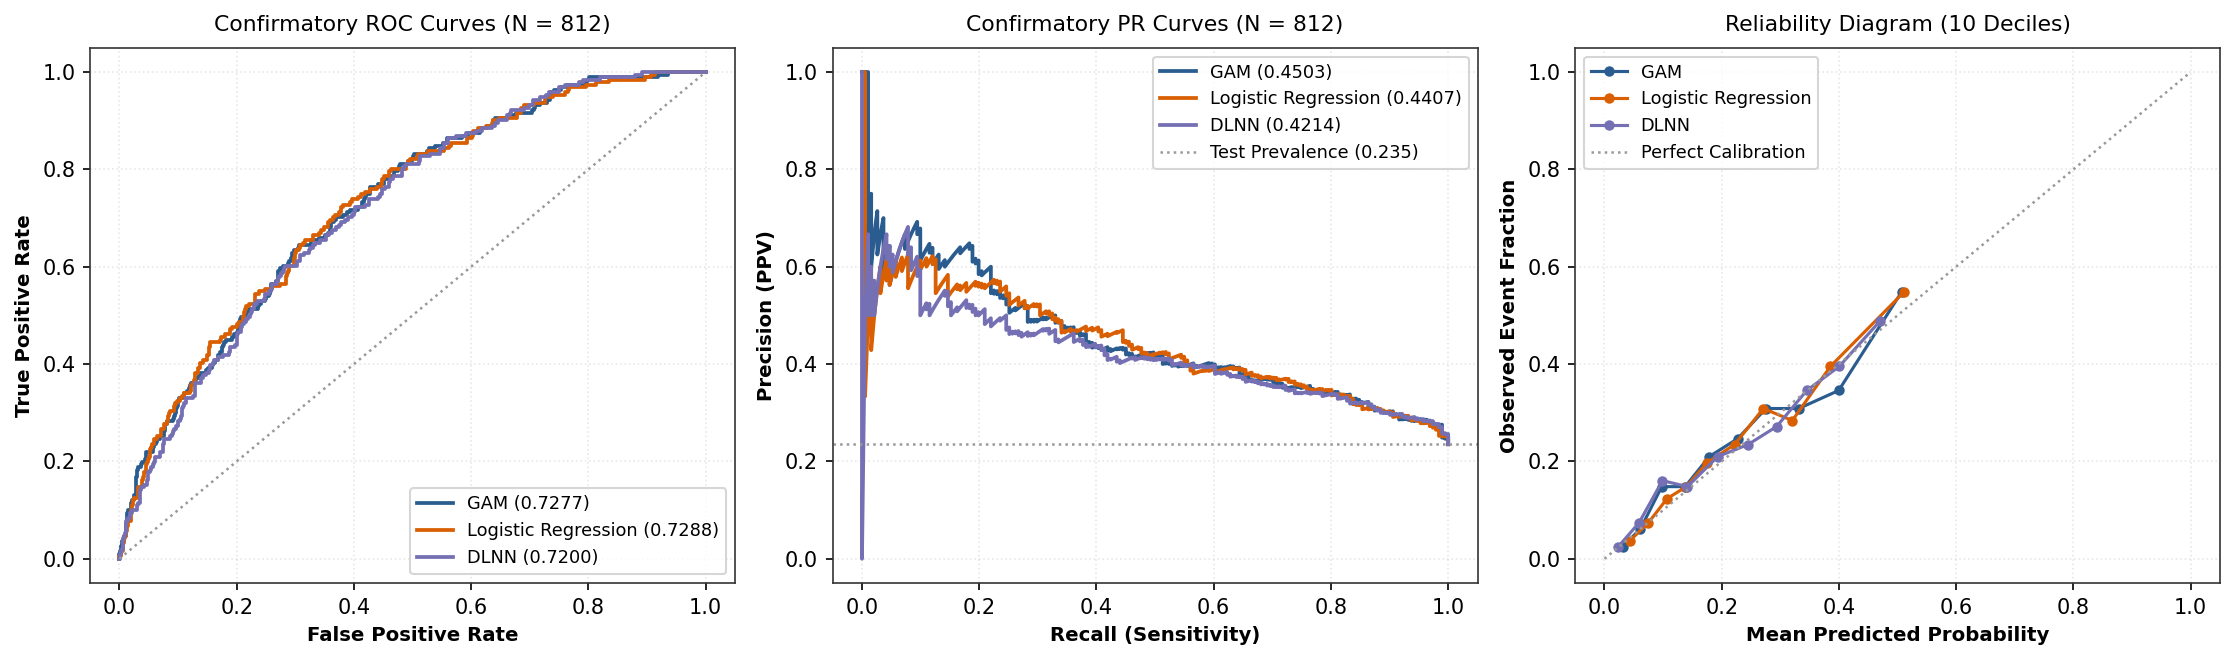

In [10]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.5), dpi=150)

colors = {"GAM": "#2b5c8f", "Logistic_Regression": "#d95f02", "DLNN": "#7570b3"}

for name, col in models.items():
    p = preds_df[col].values
    
    # ROC
    fpr, tpr, _ = roc_curve(y_true, p)
    roc_val = roc_auc_score(y_true, p)
    ax1.plot(fpr, tpr, color=colors[name], lw=1.8, label=f"{name.replace('_', ' ')} ({roc_val:.4f})")
    
    # PR
    prec, rec, _ = precision_recall_curve(y_true, p)
    pr_val = average_precision_score(y_true, p)
    ax2.plot(rec, prec, color=colors[name], lw=1.8, label=f"{name.replace('_', ' ')} ({pr_val:.4f})")
    
    # Calibration
    prob_true, prob_pred = calibration_curve(y_true, p, n_bins=10, strategy="quantile")
    ax3.plot(prob_pred, prob_true, marker="o", markersize=4, color=colors[name], lw=1.5, label=name.replace('_', ' '))

ax1.plot([0, 1], [0, 1], color="#999999", linestyle=":", lw=1.2)
ax1.set_xlabel("False Positive Rate", fontsize=9.5, fontweight="bold")
ax1.set_ylabel("True Positive Rate", fontsize=9.5, fontweight="bold")
ax1.set_title("Confirmatory ROC Curves (N = 812)", fontsize=10.5, pad=8)
ax1.legend(loc="lower right", fontsize=8.5)
ax1.grid(alpha=0.3, linestyle=":")

ax2.axhline(0.2352, color="#999999", linestyle=":", lw=1.2, label="Test Prevalence (0.235)")
ax2.set_xlabel("Recall (Sensitivity)", fontsize=9.5, fontweight="bold")
ax2.set_ylabel("Precision (PPV)", fontsize=9.5, fontweight="bold")
ax2.set_title("Confirmatory PR Curves (N = 812)", fontsize=10.5, pad=8)
ax2.legend(loc="upper right", fontsize=8.5)
ax2.grid(alpha=0.3, linestyle=":")

ax3.plot([0, 1], [0, 1], color="#999999", linestyle=":", lw=1.2, label="Perfect Calibration")
ax3.set_xlabel("Mean Predicted Probability", fontsize=9.5, fontweight="bold")
ax3.set_ylabel("Observed Event Fraction", fontsize=9.5, fontweight="bold")
ax3.set_title("Reliability Diagram (10 Deciles)", fontsize=10.5, pad=8)
ax3.legend(loc="upper left", fontsize=8.5)
ax3.grid(alpha=0.3, linestyle=":")

plt.show()


## 12. Final Takeaways & Post-Test Governance Statement

1. **Confirmatory Verdict:** On the held-out test cohort, the pre-specified primary GAM demonstrated robust discrimination (ROC-AUC $0.7277$, PR-AUC $0.4503$) and reliable probability calibration, broadly comparable to linear Logistic Regression while outperforming DLNN.
2. **Clinical Screening Balance:** At the frozen operating threshold ($0.1389$), the model captured $86.39\%$ of true unrecognized dysglycemic adults, requiring $3.16$ laboratory tests per detected case while filtering out $42.51\%$ of healthy individuals.
3. **No External Extrapolation Claim:** As documented in the study protocol, these metrics reflect unweighted participant-level predictive accuracy on the NHANES screening cohort. They must **not** be claimed as nationally representative U.S. prevalence estimates, nor do they claim external validity to the Indonesian population.
4. **Permanent Audit Close:** This notebook performed strictly read-only verification. **No post-test model tuning, hyperparameter search, or threshold recalculation was conducted.**
